In [1]:
# Force a stable Pillow version and update transformers
!pip install "pillow<11.0" transformers torch torchvision requests --quiet

print("✅ Installation complete. NOW RESTART YOUR RUNTIME (Runtime > Restart session) before running the next cell!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 62.6 MB/s eta 0:00:00
✅ Installation complete. NOW RESTART YOUR RUNTIME (Runtime > Restart session) before running the next cell!


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/276M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/782 [00:01<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/537 [00:00<?, ?B/s]

`label_ids_to_fuse` unset. No instance will be fused.


Detected 2 objects.
Found: dog
Found: dog


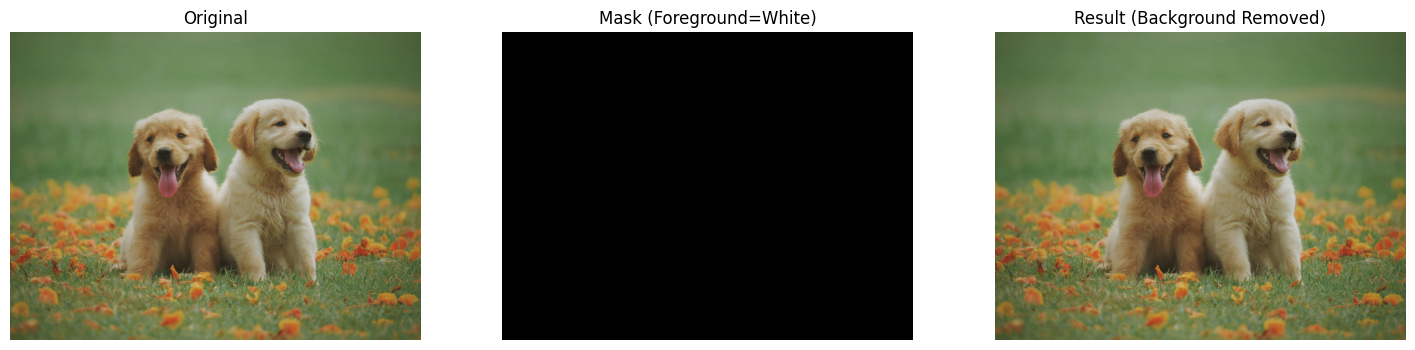

In [4]:
# 1. Standard installs
!pip install -q transformers torch torchvision pillow

import torch
import numpy as np
import requests
import matplotlib.pyplot as plt
from PIL import Image
from transformers import pipeline

# 2. Load the segmenter
# Using a slightly larger model for better accuracy on fine details like dog fur
segmenter = pipeline(
    "image-segmentation",
    model="facebook/mask2former-swin-small-coco-instance",
    device=0 if torch.cuda.is_available() else -1
)

# 3. Load Image
url = "https://images.pexels.com/photos/1108099/pexels-photo-1108099.jpeg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

# 4. Run Inference
# We lower the threshold to 0.5 to make sure it captures the objects
outputs = segmenter(image, threshold=0.5)

# 5. Process & Combine Masks
if outputs:
    print(f"Detected {len(outputs)} objects.")
    width, height = image.size
    # Initialize a blank boolean mask
    final_mask = np.zeros((height, width), dtype=bool)

    for obj in outputs:
        print(f"Found: {obj['label']}")
        # Convert the PIL mask returned by pipeline to a boolean numpy array
        m = np.array(obj['mask']) > 0
        final_mask = np.logical_or(final_mask, m)

    # 6. Apply Background Removal
    img_array = np.array(image)
    result = img_array.copy()

    # Masking: where final_mask is False, set to Black (0,0,0) or White (255,255,255)
    result[~final_mask] = [0, 0, 0]

    # 7. Final Visualization (Matches your screenshot layout)
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(final_mask, cmap='gray')
    plt.title("Mask (Foreground=White)")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(result)
    plt.title("Result (Background Removed)")
    plt.axis('off')

    plt.show()
else:
    print("❌ No objects detected! Try a different image or lower the threshold.")